In [1]:
#!pip install ewl

In [30]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.ioff()

In [31]:
# enable lokal import
import sys
from pathlib import Path

ROOT_DIR = Path.cwd().parent  
SRC_DIR = ROOT_DIR / "src"

sys.path.insert(0, str(SRC_DIR)) 

In [32]:
from ewl import EWL

from ewl.parametrizations import U_theta_alpha_beta

import sympy as sp
from sympy import Array, Matrix
from sympy.physics.quantum.qubit import Qubit


from qiskit.visualization import plot_histogram

sp.init_printing()


i = sp.I
pi = sp.pi
sqrt2 = sp.sqrt(2)

In [33]:
psi = (Qubit('00') + i * Qubit('11')) / sqrt2
psi

In [34]:
C = Matrix([
    [1, 0],
    [0, 1],
])
C

⎡1  0⎤
⎢    ⎥
⎣0  1⎦

In [35]:
D = Matrix([
    [0, i],
    [i, 0],
])
D

⎡0  ⅈ⎤
⎢    ⎥
⎣ⅈ  0⎦

In [36]:
theta1, alpha1, beta1 = sp.symbols('theta1 alpha1 beta1', real=True)
alice = U_theta_alpha_beta(theta=theta1, alpha=alpha1, beta=beta1)
alice

⎡  ⅈ⋅α₁    ⎛θ₁⎞       ⅈ⋅β₁    ⎛θ₁⎞⎤
⎢ ℯ    ⋅cos⎜──⎟    ⅈ⋅ℯ    ⋅sin⎜──⎟⎥
⎢          ⎝2 ⎠               ⎝2 ⎠⎥
⎢                                 ⎥
⎢   -ⅈ⋅β₁    ⎛θ₁⎞   -ⅈ⋅α₁    ⎛θ₁⎞ ⎥
⎢ⅈ⋅ℯ     ⋅sin⎜──⎟  ℯ     ⋅cos⎜──⎟ ⎥
⎣            ⎝2 ⎠            ⎝2 ⎠ ⎦

In [37]:
theta2, alpha2, beta2 = sp.symbols('theta2 alpha2 beta2', real=True)
bob = U_theta_alpha_beta(theta=theta2, alpha=alpha2, beta=beta2)
bob

⎡  ⅈ⋅α₂    ⎛θ₂⎞       ⅈ⋅β₂    ⎛θ₂⎞⎤
⎢ ℯ    ⋅cos⎜──⎟    ⅈ⋅ℯ    ⋅sin⎜──⎟⎥
⎢          ⎝2 ⎠               ⎝2 ⎠⎥
⎢                                 ⎥
⎢   -ⅈ⋅β₂    ⎛θ₂⎞   -ⅈ⋅α₂    ⎛θ₂⎞ ⎥
⎢ⅈ⋅ℯ     ⋅sin⎜──⎟  ℯ     ⋅cos⎜──⎟ ⎥
⎣            ⎝2 ⎠            ⎝2 ⎠ ⎦

In [38]:
payoff_matrix = Array([
    [
        [3, 0],
        [5, 1],
    ],
    [
        [3, 5],
        [0, 1],
    ],
])
payoff_matrix

⎡⎡3  0⎤  ⎡3  5⎤⎤
⎢⎢    ⎥  ⎢    ⎥⎥
⎣⎣5  1⎦  ⎣0  1⎦⎦

In [39]:
ewl = EWL(psi=psi, C=C, D=D, players=[alice, bob], payoff_matrix=payoff_matrix)
ewl

In [40]:
ewl.J

⎡ √2               -√2⋅ⅈ ⎤
⎢ ──    0     0    ──────⎥
⎢ 2                  2   ⎥
⎢                        ⎥
⎢      √2⋅ⅈ  -√2         ⎥
⎢ 0    ────  ────    0   ⎥
⎢       2     2          ⎥
⎢                        ⎥
⎢      -√2   √2⋅ⅈ        ⎥
⎢ 0    ────  ────    0   ⎥
⎢       2     2          ⎥
⎢                        ⎥
⎢√2⋅ⅈ               -√2  ⎥
⎢────   0     0     ──── ⎥
⎣ 2                  2   ⎦

In [41]:
ewl.J_H

⎡ √2                   -√2⋅ⅈ ⎤
⎢ ──     0       0     ──────⎥
⎢ 2                      2   ⎥
⎢                            ⎥
⎢      -√2⋅ⅈ    -√2          ⎥
⎢ 0    ──────   ────     0   ⎥
⎢        2       2           ⎥
⎢                            ⎥
⎢       -√2    -√2⋅ⅈ         ⎥
⎢ 0     ────   ──────    0   ⎥
⎢        2       2           ⎥
⎢                            ⎥
⎢√2⋅ⅈ                   -√2  ⎥
⎢────    0       0      ──── ⎥
⎣ 2                      2   ⎦

In [42]:
ewl.amplitudes(simplify=False)

⎡    ⎛    ⅈ⋅α₁  ⅈ⋅α₂    ⎛θ₁⎞    ⎛θ₂⎞         -ⅈ⋅β₁  -ⅈ⋅β₂    ⎛θ₁⎞    ⎛θ₂⎞⎞     ↪
⎢    ⎜√2⋅ℯ    ⋅ℯ    ⋅cos⎜──⎟⋅cos⎜──⎟   √2⋅ⅈ⋅ℯ     ⋅ℯ     ⋅sin⎜──⎟⋅sin⎜──⎟⎟     ↪
⎢    ⎜                  ⎝2 ⎠    ⎝2 ⎠                         ⎝2 ⎠    ⎝2 ⎠⎟     ↪
⎢ √2⋅⎜────────────────────────────── + ──────────────────────────────────⎟   √ ↪
⎢    ⎝              2                                  2                 ⎠     ↪
⎢ ──────────────────────────────────────────────────────────────────────── + ─ ↪
⎢                                    2                                         ↪
⎢                                                                              ↪
⎢     ⎛    ⅈ⋅α₁  -ⅈ⋅β₂    ⎛θ₂⎞    ⎛θ₁⎞         ⅈ⋅α₂  -ⅈ⋅β₁    ⎛θ₁⎞    ⎛θ₂⎞⎞    ↪
⎢     ⎜√2⋅ℯ    ⋅ℯ     ⋅sin⎜──⎟⋅cos⎜──⎟   √2⋅ⅈ⋅ℯ    ⋅ℯ     ⋅sin⎜──⎟⋅cos⎜──⎟⎟    ↪
⎢     ⎜                   ⎝2 ⎠    ⎝2 ⎠                        ⎝2 ⎠    ⎝2 ⎠⎟    ↪
⎢  √2⋅⎜─────────────────────────────── - ─────────────────────────────────⎟    ↪
⎢     ⎝               2     

In [43]:
ewl.amplitudes()

⎡   ⎛θ₁⎞    ⎛θ₂⎞                   ⎛θ₁⎞    ⎛θ₂⎞             ⎤
⎢sin⎜──⎟⋅sin⎜──⎟⋅sin(β₁ + β₂) + cos⎜──⎟⋅cos⎜──⎟⋅cos(α₁ + α₂)⎥
⎢   ⎝2 ⎠    ⎝2 ⎠                   ⎝2 ⎠    ⎝2 ⎠             ⎥
⎢                                                           ⎥
⎢   ⎛θ₁⎞                 ⎛θ₂⎞      ⎛θ₂⎞    ⎛θ₁⎞             ⎥
⎢sin⎜──⎟⋅sin(α₂ - β₁)⋅cos⎜──⎟ + sin⎜──⎟⋅cos⎜──⎟⋅cos(α₁ - β₂)⎥
⎢   ⎝2 ⎠                 ⎝2 ⎠      ⎝2 ⎠    ⎝2 ⎠             ⎥
⎢                                                           ⎥
⎢   ⎛θ₁⎞    ⎛θ₂⎞                   ⎛θ₂⎞                 ⎛θ₁⎞⎥
⎢sin⎜──⎟⋅cos⎜──⎟⋅cos(α₂ - β₁) + sin⎜──⎟⋅sin(α₁ - β₂)⋅cos⎜──⎟⎥
⎢   ⎝2 ⎠    ⎝2 ⎠                   ⎝2 ⎠                 ⎝2 ⎠⎥
⎢                                                           ⎥
⎢   ⎛θ₁⎞    ⎛θ₂⎞                                ⎛θ₁⎞    ⎛θ₂⎞⎥
⎢sin⎜──⎟⋅sin⎜──⎟⋅cos(β₁ + β₂) - sin(α₁ + α₂)⋅cos⎜──⎟⋅cos⎜──⎟⎥
⎣   ⎝2 ⎠    ⎝2 ⎠                                ⎝2 ⎠    ⎝2 ⎠⎦

In [44]:
ewl.probs()

⎡                                                             2⎤
⎢⎛   ⎛θ₁⎞    ⎛θ₂⎞                   ⎛θ₁⎞    ⎛θ₂⎞             ⎞ ⎥
⎢⎜sin⎜──⎟⋅sin⎜──⎟⋅sin(β₁ + β₂) + cos⎜──⎟⋅cos⎜──⎟⋅cos(α₁ + α₂)⎟ ⎥
⎢⎝   ⎝2 ⎠    ⎝2 ⎠                   ⎝2 ⎠    ⎝2 ⎠             ⎠ ⎥
⎢                                                              ⎥
⎢                                                             2⎥
⎢⎛   ⎛θ₁⎞                 ⎛θ₂⎞      ⎛θ₂⎞    ⎛θ₁⎞             ⎞ ⎥
⎢⎜sin⎜──⎟⋅sin(α₂ - β₁)⋅cos⎜──⎟ + sin⎜──⎟⋅cos⎜──⎟⋅cos(α₁ - β₂)⎟ ⎥
⎢⎝   ⎝2 ⎠                 ⎝2 ⎠      ⎝2 ⎠    ⎝2 ⎠             ⎠ ⎥
⎢                                                              ⎥
⎢                                                             2⎥
⎢⎛   ⎛θ₁⎞    ⎛θ₂⎞                   ⎛θ₂⎞                 ⎛θ₁⎞⎞ ⎥
⎢⎜sin⎜──⎟⋅cos⎜──⎟⋅cos(α₂ - β₁) + sin⎜──⎟⋅sin(α₁ - β₂)⋅cos⎜──⎟⎟ ⎥
⎢⎝   ⎝2 ⎠    ⎝2 ⎠                   ⎝2 ⎠                 ⎝2 ⎠⎠ ⎥
⎢                                                              ⎥
⎢                        

In [45]:
ewl.payoff_function(player=0)

In [46]:
ewl.payoff_function(player=1)

In [47]:
ewl.payoff_function(player=None)

In [48]:
ewl.params

In [49]:
ewl_fixed = ewl.fix(theta1=pi / 2, alpha1=pi / 2, beta1=0,
                    theta2=0, alpha2=0, beta2=0)

In [50]:
ewl_fixed.params

In [51]:
#from qiskit_ibm_runtime import QiskitRuntimeService
#service = QiskitRuntimeService(
 #   region="us-east",
 #   plans_preference=["open"], instance="open-instance"
#)

In [60]:
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
    token="x5gju1I-OamNU_BKlJaygnlvqxhE8rfackVhPgDvBQ9E",  # z IBM Quantum dashboard
    instance="open-instance",   # Twoja instancja z warningu
    set_as_default=True,        # Ustaw jako domyślną!
    overwrite=True              # Nadpisz jeśli istnieje
)

In [52]:
from ewl.ibmq import EWL_IBMQ
ewl_ibmq = EWL_IBMQ(ewl_fixed)
ewl_ibmq

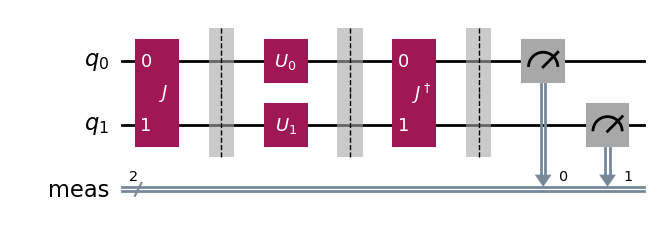

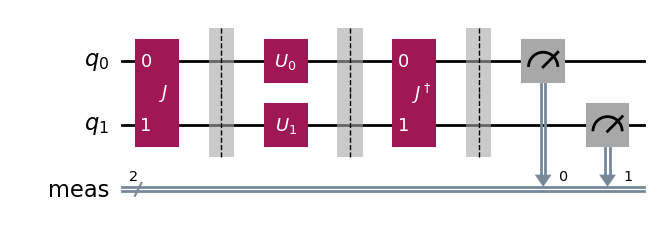

In [53]:
ewl_ibmq.draw()

qiskit_runtime_service.__init__:WARNING:2026-01-29 11:31:47,372: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-01-29 11:31:47,376: Using instance: open-instance, plan: open


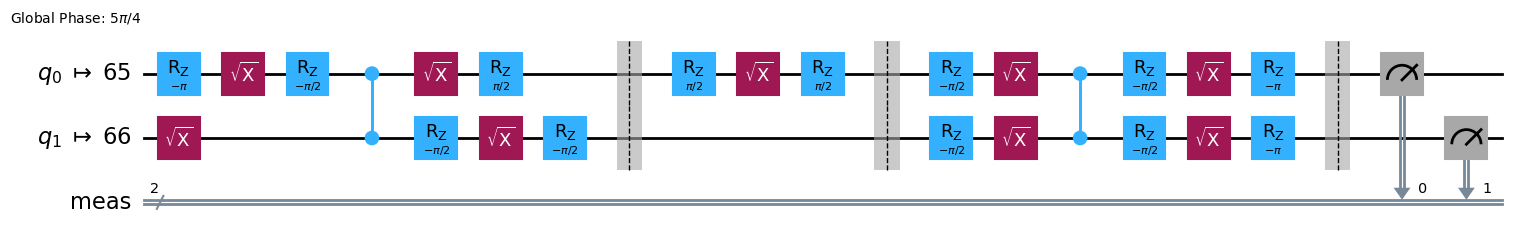

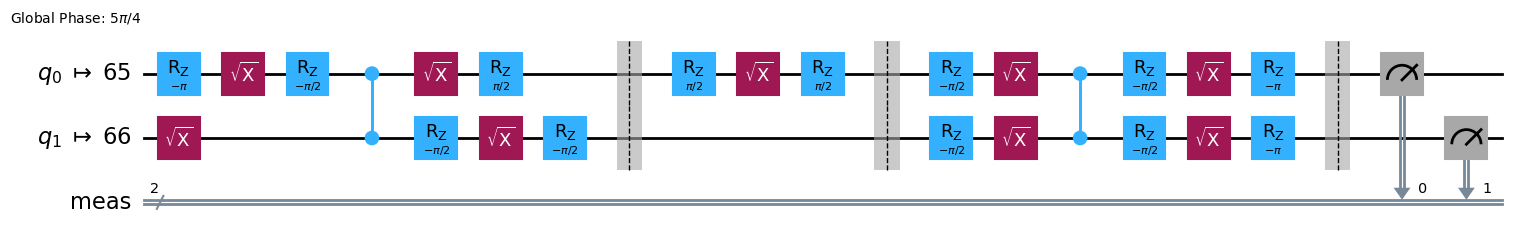

In [54]:
ewl_ibmq.draw_transpiled(backend_name='ibm_torino', optimization_level=3, fold=-1)

{np.str_('01'): np.float64(0.5000000000000002), np.str_('11'): np.float64(0.5000000000000002)}


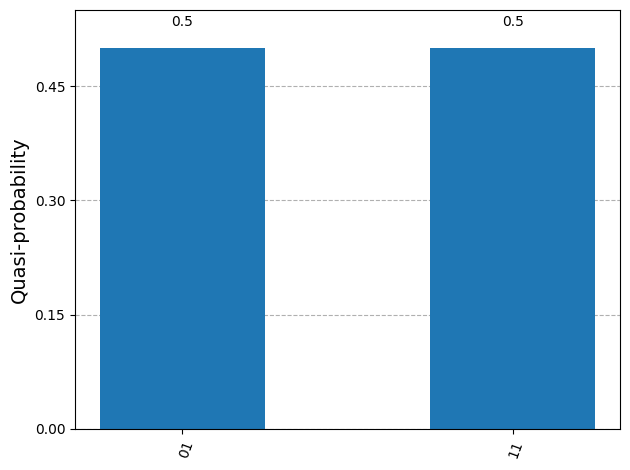

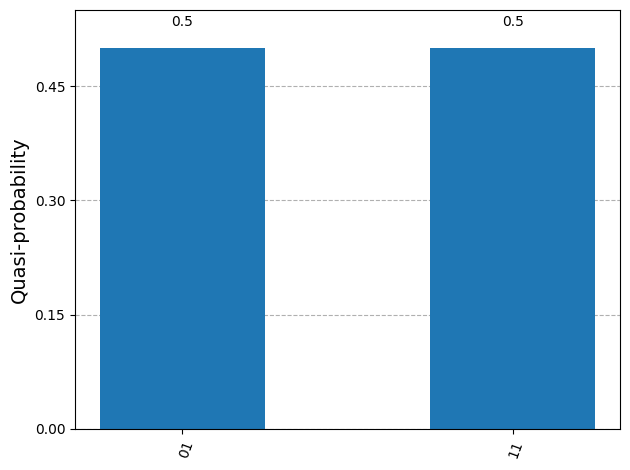

In [57]:
probs = ewl_ibmq.simulate_probs()
print(probs)
plot_histogram(probs)

{np.str_('01'): np.int64(514), np.str_('11'): np.int64(510)}


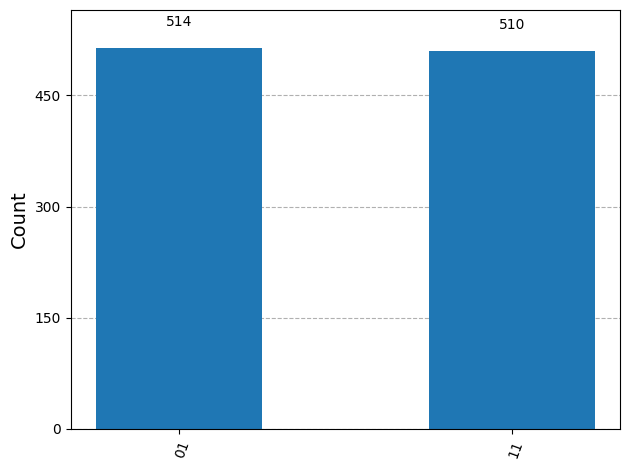

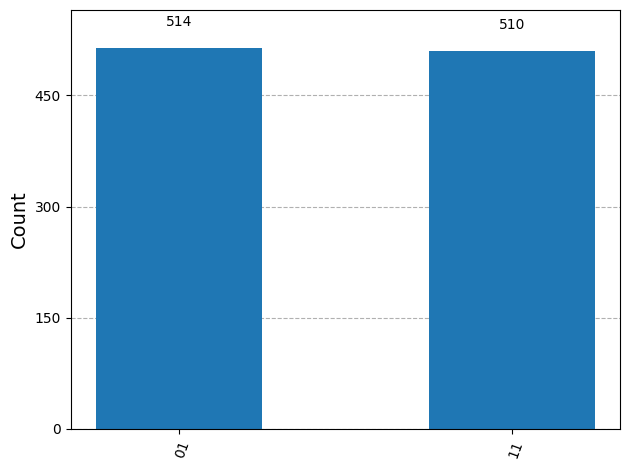

In [27]:
counts_qasm_simulator = ewl_ibmq.simulate_counts()
print(counts_qasm_simulator)
plot_histogram(counts_qasm_simulator)

qiskit_runtime_service.backends:WARNING:2026-01-29 11:29:50,395: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-01-29 11:29:51,969: Using instance: open-instance, plan: open


{'01': 524, '11': 473, '10': 15, '00': 12}


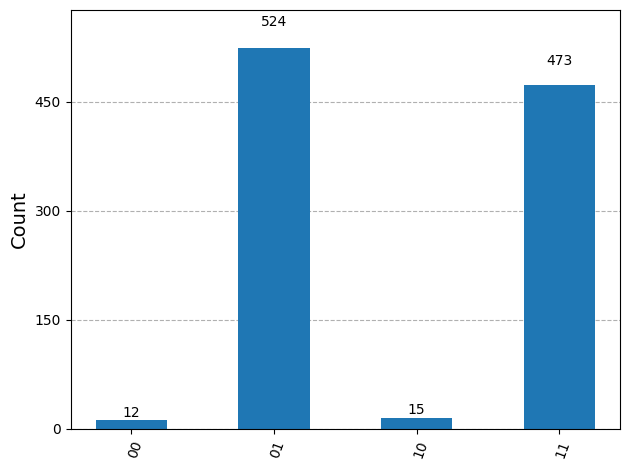

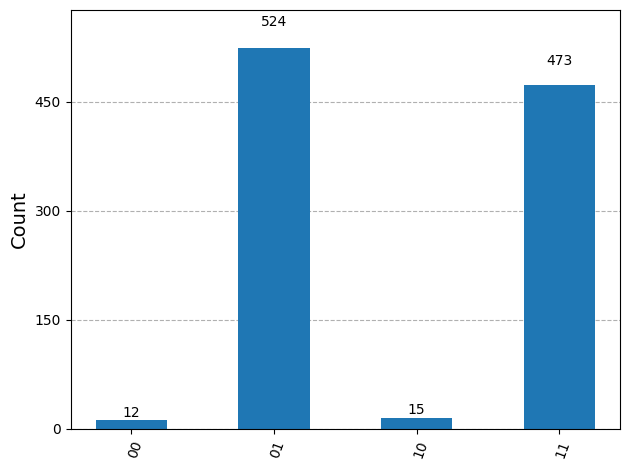

In [28]:
counts_quantum_device = ewl_ibmq.run()
print(counts_quantum_device)
plot_histogram(counts_quantum_device)

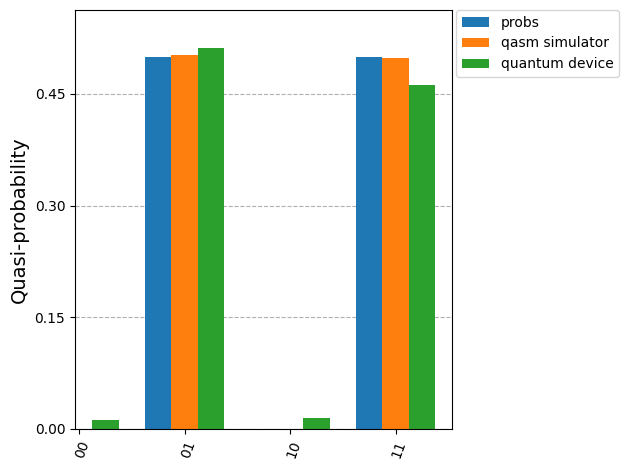

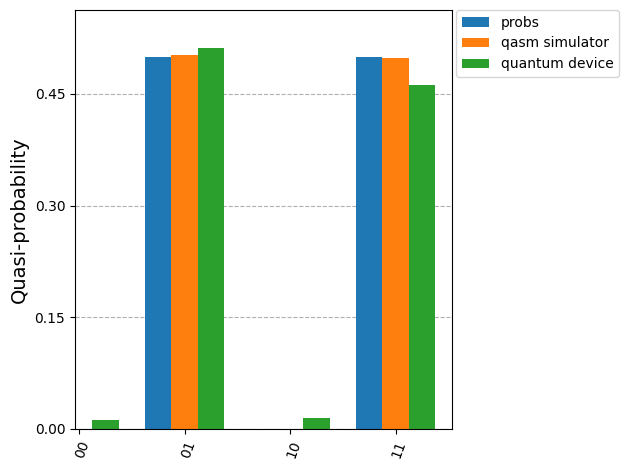

In [29]:
binary_prob = [probs, counts_qasm_simulator, counts_quantum_device]
plot_histogram(
    binary_prob,
    bar_labels=False,
    legend=['probs', 'qasm simulator', 'quantum device']       
)